# The escalated case: which branch Meera opens first, solution

**Week 1, Monday, afternoon. Rung 5, unguided, 60 minutes, alone.** The morning's three rounds
gave you the definition, the leaves and the honest typical order. This notebook asks you to put
them together into the answer Meera takes to the board, on the same 30 orders from 1 July to
26 September 2026.

Meera Raghavan, CEO of Kalpa Retail, before she signs the Rs 12 crore marketing has asked for:
"Before I sign anything, I want to understand our own sales. What is 'sales' made of? Where does
revenue come from, by customer type and channel? Is acquisition even the branch that is short?"
Anand Iyer, the finance controller, has already said: "No averages. One business customer can
move an average."

> **Kavya's review.** "The morning gave you three honest numbers. Meera does not want three rounds
> of working; she wants one answer she can defend on Thursday: the branch to open first, the number
> that shows it, and what this file cannot tell her. Put the definition beside every number, and
> recompute anything marketing adds up."

Every placeholder is filled with the right option, and the notebook was executed from a fresh kernel. Under each step sits the reason the other three options fail, and part 3 stages the plausible wrong answer with its exact number.

**The answer string:** `cbadcdacbbad`.

The setup cell reaches the shared helper and loads the 30 orders. The amount stored as text that
round 2 met is converted once here with `int()`, the fix round 2 settled on, so every sum below
runs on whole numbers.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

ORDERS = kit.load_records()
for order in ORDERS:
    order["amount"] = int(order["amount"])
print(len(ORDERS), "orders loaded, every amount now a whole number")

30 orders loaded, every amount now a whole number


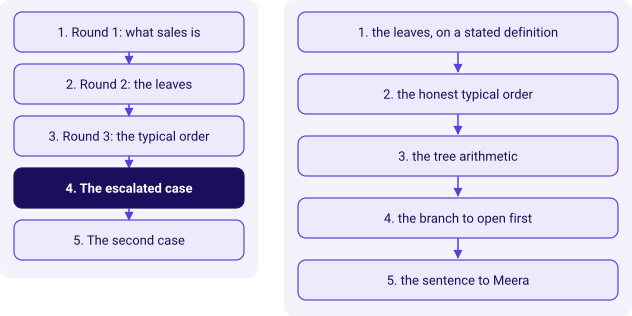

In [2]:
kit.side_by_side(
    kit.ladder(["Round 1: what sales is", "Round 2: the leaves", "Round 3: the typical order",
                "The escalated case", "The second case"], lit=3, show=False),
    kit.vflow(["1. the leaves, on a stated definition", "2. the honest typical order",
               "3. the tree arithmetic", "4. the branch to open first",
               "5. the sentence to Meera"], show=False),
)

## Part 1. The leaves, on a definition you state

Meera asked what "sales" is made of, so every leaf goes to her with its definition beside it. The
note uses booked orders, the whole file, as its base, and the delivered leaves sit beside them so
Meera sees what the definition moves. Build the delivered list, count its customers by id, and
compute orders per customer on it.

**Post:** delivered orders, delivered customers and delivered orders per customer.

Leaf,"Booked, all 30 orders",Delivered only
orders,30,21
"customers, by id",23,19
orders per customer,1.30,1.11
revenue,"Rs 5,44,810","Rs 5,20,790"


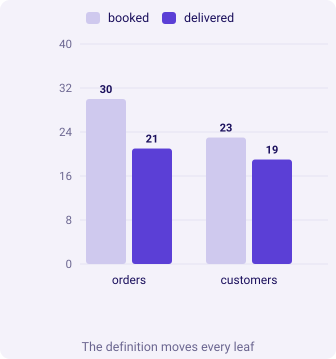

In [3]:
booked_ids = []
booked_revenue = 0
for order in ORDERS:
    booked_ids.append(order["customer_id"])
    booked_revenue += order["amount"]
booked_customers = len(set(booked_ids))      # round 2's count

# TODO 1. Which condition keeps the orders that reached a customer and stayed there?
#   a) order["status"] != "cancelled"
#   b) order["status"] in ("delivered", "returned")
#   c) order["status"] == "delivered"
#   d) order["amount"] > 0
delivered = []
delivered_ids = []
delivered_revenue = 0
for order in ORDERS:
    if order["status"] == "delivered":
        delivered.append(order)
        delivered_ids.append(order["customer_id"])
        delivered_revenue += order["amount"]

# TODO 2. Which expression counts the distinct customers behind the delivered orders?
#   a) len(delivered_ids)
#   b) len(set(delivered_ids))
#   c) len(set(booked_ids))
#   d) len(set(booked_ids[:21]))
delivered_customers = len(set(delivered_ids))

# TODO 3. Which expression is orders per customer on the delivered definition?
#   a) delivered_customers / len(delivered)
#   b) len(ORDERS) / delivered_customers
#   c) len(delivered) / booked_customers
#   d) len(delivered) / delivered_customers
delivered_per_customer = len(delivered) / delivered_customers
booked_per_customer = len(ORDERS) / booked_customers

kit.table(["Leaf", "Booked, all 30 orders", "Delivered only"], [
    ("orders", len(ORDERS), len(delivered)),
    ("customers, by id", booked_customers, delivered_customers),
    ("orders per customer", f"{booked_per_customer:.2f}", f"{delivered_per_customer:.2f}"),
    ("revenue", kit.rupees(booked_revenue), kit.rupees(delivered_revenue)),
], caption="The same file on two definitions, 1 July to 26 September 2026")
kit.columns(["orders", "customers"],
            [("booked", [len(ORDERS), booked_customers]),
             ("delivered", [len(delivered), delivered_customers])],
            title="The definition moves every leaf", fmt=lambda v: f"{v:.0f}")

In [4]:
kit.check("21 orders were delivered", len(delivered) == 21, f"got {len(delivered)}")
kit.check("delivered customers are counted by id, fewer than delivered orders",
          delivered_customers < len(delivered), f"{delivered_customers} customers")
kit.check("delivered orders per customer sits above one", delivered_per_customer > 1,
          f"{delivered_per_customer:.2f}")
kit.check("booked revenue sits above delivered revenue",
          booked_revenue >= delivered_revenue > 0,
          f"{kit.rupees(booked_revenue)} booked, {kit.rupees(delivered_revenue)} delivered")

**Why not the others.** In TODO 1, option a keeps returned orders, which did not stay sold; b keeps
them on purpose, which is a different definition; d keeps every order, since every amount is above
zero. In TODO 2, option a counts rows, so a customer with two delivered orders counts twice; c counts
booked customers, which mixes two definitions in one leaf; d takes the first 21 ids of the file,
which are not the delivered ones. In TODO 3, option a is the rate upside down; b puts booked orders
over delivered customers; c puts delivered orders over booked customers.

**What the definition changes.** Delivered leaves 21 orders from 19 customers, 1.11 orders each,
and Rs 5,20,790 of revenue. Booked is 30 orders from 23 customers, 1.30 each, and Rs 5,44,810. The
note to Meera states booked, the whole quarter's demand, and says so beside the number; either
definition is honest when it is named.

## Part 2. The honest typical order

Anand's rule is no averages, and the reason has to be shown on this file. Sort the 30 booked
amounts, take the median of an even count, and count how many orders sit above the mean.

**Post:** the mean, the median, and the number of orders above the mean.

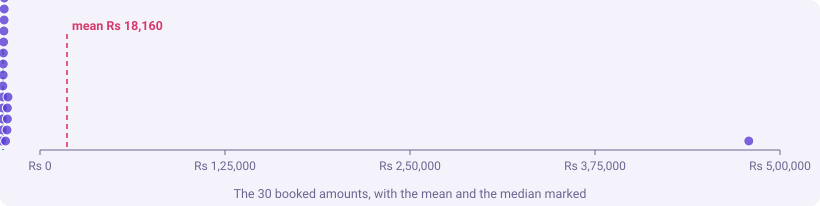

In [5]:
amounts = []
for order in ORDERS:
    amounts.append(order["amount"])
amounts.sort()
n = len(amounts)
mean_order = sum(amounts) / n

# TODO 4. n is 30, an even count. Which expression is the median?
#   a) (amounts[n // 2] + amounts[n // 2 + 1]) / 2
#   b) amounts[n // 2]
#   c) sum(amounts) / n
#   d) (amounts[n // 2 - 1] + amounts[n // 2]) / 2
median_order = (amounts[n // 2 - 1] + amounts[n // 2]) / 2

# TODO 5. Which test counts an order as sitting above the mean?
#   a) amount > median_order
#   b) amount >= 0
#   c) amount > mean_order
#   d) amount < mean_order
above_mean = 0
for amount in amounts:
    if amount > mean_order:
        above_mean += 1

kit.stats([
    (kit.rupees(round(mean_order)), "mean order", "every booked amount, summed and divided by 30"),
    (kit.rupees(round(median_order)), "median order", "the middle of the sorted 30"),
    (f"{above_mean} of {n}", "orders above the mean", "the rest sit below it"),
])
kit.strip(amounts, markers=[("mean", mean_order, "bad"), ("median", median_order, "good")],
          title="The 30 booked amounts, with the mean and the median marked")

In [6]:
kit.check("the median is a whole number of rupees on this file", median_order == int(median_order),
          kit.rupees(round(median_order)))
kit.check("the mean sits more than eight times above the median", mean_order > 8 * median_order,
          f"{mean_order / median_order:.1f} times")
kit.check("almost every order sits below the mean", n - above_mean >= 29,
          f"{n - above_mean} of {n} below")

**Why not the others.** In TODO 4, option a is one place past the middle pair; b is the upper of the
two middles, a single value where an even count needs two; c is the mean. In TODO 5, option a counts
orders above the median, which is half the file by construction; b counts every order; d counts the
orders below the mean, the other side of the same question.

**Why the median is the honest typical order.** The mean is Rs 18,160 and the median Rs 2,205, about
one eighth of it, and 29 of the 30 orders sit below the mean. One order, the one your round 3 sort
put at the top, drags the mean above every ordinary order, which is exactly what Anand warned about.
A first order from a new customer is worth about Rs 2,205, so marketing's payback arithmetic needs
about eight times as many orders as the mean suggested.

## Part 3. The tree arithmetic

The marketing lead's pitch to Meera: "A 10 percent lift in customers and a 10 percent lift in orders
per customer make 20 percent growth." Before that sentence reaches the board, recompute revenue
through the tree. First check that the three branches multiply back to booked revenue, then lift
two of them, then ask what the 15 percent plan needs from one branch alone, and finally price
the discount marketing will propose next.

**Post:** revenue after both lifts, the growth it makes, and what the plan needs from customers
alone and from orders alone.

23 customers x 1.30 orders each x Rs 18,160 per order = Rs 5,44,810


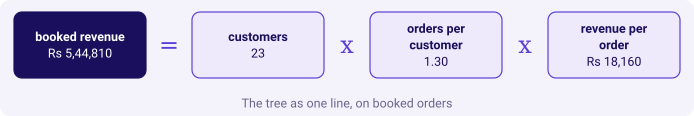

In [7]:
customers = booked_customers
per_customer = len(ORDERS) / customers
per_order = booked_revenue / len(ORDERS)
rebuilt = customers * per_customer * per_order
print(f"{customers} customers x {per_customer:.2f} orders each x {kit.rupees(round(per_order))} "
      f"per order = {kit.rupees(round(rebuilt))}")
kit.equation(["booked revenue\n" + kit.rupees(booked_revenue), "=",
              "customers\n" + str(customers), "x",
              "orders per customer\n" + f"{per_customer:.2f}", "x",
              "revenue per order\n" + kit.rupees(round(per_order))],
             title="The tree as one line, on booked orders")

In [8]:
kit.check("the three branches multiply back to booked revenue", abs(rebuilt - booked_revenue) < 1,
          f"{kit.rupees(round(rebuilt))} against {kit.rupees(booked_revenue)}")

through the tree: Rs 6,59,220, growth 21 percent
marketing's figure: Rs 6,53,772, a gap of Rs 5,448


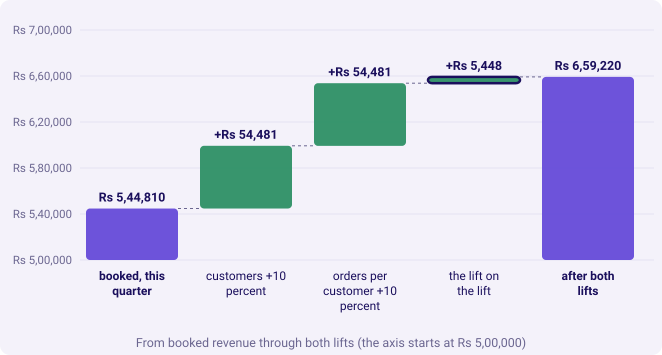

In [9]:
# TODO 6. Which expression is revenue after both 10 percent lifts, computed through the tree?
#   a) booked_revenue * (1 + 0.10 + 0.10)
#   b) booked_revenue * 1.10 + booked_revenue * 1.10 - booked_revenue
#   c) (customers + 0.10) * (per_customer + 0.10) * per_order
#   d) (customers * 1.10) * (per_customer * 1.10) * per_order
after_both = (customers * 1.10) * (per_customer * 1.10) * per_order
growth = after_both / booked_revenue - 1
marketing_says = booked_revenue * 1.20
print(f"through the tree: {kit.rupees(round(after_both))}, growth {growth * 100:.0f} percent")
print(f"marketing's figure: {kit.rupees(round(marketing_says))}, "
      f"a gap of {kit.rupees(round(after_both - marketing_says))}")
kit.bridge(("booked, this quarter", booked_revenue),
           [("customers +10 percent", round(booked_revenue * 0.10)),
            ("orders per customer +10 percent", round(booked_revenue * 0.10)),
            ("the lift on the lift", round(after_both - marketing_says))],
           end_label="after both lifts", lit=(2,), lo=500000,
           title="From booked revenue through both lifts (the axis starts at Rs 5,00,000)")

In [10]:
kit.check("revenue after both lifts is rebuilt leaf by leaf through the tree",
          abs(after_both - (customers * 1.10) * (per_customer * 1.10) * per_order) < 1,
          kit.rupees(round(after_both)))
kit.check("two lifts along the tree make more than their sum",
          after_both > marketing_says, f"growth {growth * 100:.1f} percent")

**Why not the others.** Option a adds the two percentages, which is marketing's 20 percent; b adds
two lifted totals and takes one base away, the same 20 percent written longer; c adds 0.10 of a
customer and 0.10 of an order to each branch, which lifts nothing by 10 percent.

**The plausible wrong answer.** Two 10 percent lifts make 20 percent, so revenue goes from
Rs 5,44,810 to Rs 6,53,772, and marketing sizes the budget to that figure.

**Why it is wrong.** The branches multiply, so the lifts multiply too: 1.10 x 1.10 = 1.21. The second
lift applies to a customer base that is already 10 percent larger, and that lift on the lift is
revenue the addition never counts.

**The check that catches it.** Recompute revenue through the tree, leaf by leaf, and compare it with
the added percentages; the check above does exactly that, and the two numbers disagree.

**The fix.** Revenue after both lifts is Rs 6,59,220, growth of 21 percent, Rs 5,448 above
marketing's Rs 6,53,772. The gap is small at 10 percent and grows with the size and the number of
lifts, which is when a plan sized by addition misses its target.

### The 15 percent plan from one branch alone

The board's plan is 15 percent. Hold two branches where they are and ask how far the third has to
move on its own, in customers and in orders, the units a team can act on.

Branch moved alone,This quarter,The plan needs,In plain words
customers,23,26.45,about 3.45 more customers who buy like today's
orders,30,34.5,about 4.5 more orders from the 23 customers already on file
revenue per order,"Rs 18,160","Rs 20,884","Rs 2,724 more on every order"


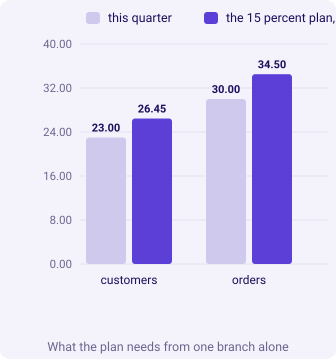

In [11]:
plan = booked_revenue * 1.15

# TODO 7. If only customers move, how many customers does the plan need?
#   a) customers * 1.15
#   b) customers + 15
#   c) plan / per_order
#   d) customers * 0.15
needed_customers = customers * 1.15

# TODO 8. If only orders per customer moves, how many orders must the same 23 customers place?
#   a) customers * 1.15
#   b) len(ORDERS) + 15
#   c) customers * per_customer * 1.15
#   d) customers * (per_customer + 0.15)
needed_orders = customers * per_customer * 1.15
needed_per_order = per_order * 1.15

kit.table(["Branch moved alone", "This quarter", "The plan needs", "In plain words"], [
    ("customers", customers, f"{needed_customers:.2f}",
     f"about {needed_customers - customers:.2f} more customers who buy like today's"),
    ("orders", len(ORDERS), f"{needed_orders:.1f}",
     f"about {needed_orders - len(ORDERS):.1f} more orders from the 23 customers already on file"),
    ("revenue per order", kit.rupees(round(per_order)), kit.rupees(round(needed_per_order)),
     f"{kit.rupees(round(needed_per_order - per_order))} more on every order"),
], caption=f"The 15 percent plan is {kit.rupees(round(plan))} of booked revenue")
kit.columns(["customers", "orders"],
            [("this quarter", [customers, len(ORDERS)]),
             ("the 15 percent plan, one branch alone", [needed_customers, needed_orders])],
            title="What the plan needs from one branch alone", fmt=lambda v: f"{v:.2f}")

In [12]:
kit.check("customers alone reach the plan through the tree",
          abs(needed_customers * per_customer * per_order - plan) < 1, f"{needed_customers:.2f}")
kit.check("orders alone reach the plan through the tree",
          abs(needed_orders * per_order - plan) < 1, f"{needed_orders:.1f} orders")

**Why not the others.** In TODO 7, option b adds fifteen customers, a 65 percent lift; c divides the
plan by revenue per order, which gives orders; d is only the extra customers, 3.45, with the base
left out. In TODO 8, option a answers the customer question again; b adds fifteen orders, a 50
percent lift; d adds 0.15 to the rate, which is an 11.5 percent lift.

**What the numbers say.** The plan is Rs 6,26,532. Customers alone need 26.45 customers, 3.45 more
who buy the way today's do. Frequency alone needs 34.5 orders from the same 23 customers, 4.5 more,
which is five of the 16 one-time buyers coming back once. Revenue per order alone needs Rs 20,884,
Rs 2,724 more on every order, and that average already carries the order at the top of the sort.

### The discount marketing will propose next

A 15 percent discount that lifts the number of orders 10 percent sounds like growth. Price it
through the tree before anyone says so.

revenue after the discount: Rs 5,09,397, a change of -6.5 percent


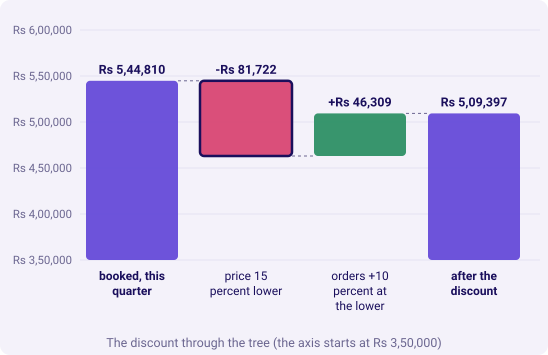

In [13]:
# TODO 9. A 15 percent discount lifts the number of orders 10 percent. What multiplies booked revenue?
#   a) 1 - 0.15 + 0.10
#   b) 0.85 * 1.10
#   c) 1.15 * 1.10
#   d) (1 - 0.15) * (1 - 0.10)
discount_factor = 0.85 * 1.10
discounted = booked_revenue * discount_factor
price_move = -round(booked_revenue * 0.15)
volume_move = round(booked_revenue * 0.85 * 0.10)
print(f"revenue after the discount: {kit.rupees(round(discounted))}, "
      f"a change of {(discount_factor - 1) * 100:.1f} percent")
kit.bridge(("booked, this quarter", booked_revenue),
           [("price 15 percent lower", price_move),
            ("orders +10 percent at the lower price", volume_move)],
           end_label="after the discount", lit=(0,), lo=350000,
           title="The discount through the tree (the axis starts at Rs 3,50,000)")

In [14]:
kit.check("the discount's two moves land on the multiplied total",
          abs(booked_revenue + price_move + volume_move - discounted) < 1,
          kit.rupees(round(discounted)))
kit.check("the discount lowers booked revenue", discounted < booked_revenue,
          f"{(discount_factor - 1) * 100:.1f} percent")

**Why not the others.** Option a adds the two moves, the same mistake as marketing's 20 percent, and
calls it a 5 percent rise; c raises the price instead of cutting it; d cuts the orders instead of
lifting them.

**What it means.** Revenue falls 6.5 percent, from Rs 5,44,810 to Rs 5,09,397, because 0.85 x 1.10 is
0.935. Orders would have to rise about 17.6 percent (1 / 0.85) before the discount paid for itself
in revenue, before any margin is counted.

## Part 4. The branch Meera opens first

Acquisition asks for new customers; frequency asks the customers Kalpa already has to come back.
Count, for each customer id, how many orders they placed, then split the customers into those who
bought once and those who came back.

**Post:** how many customers bought once, how many came back, and the branch you would open first.

16 of 23 customers bought once; 7 came back


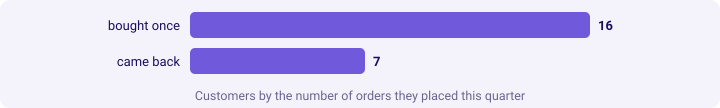

In [15]:
orders_by_customer = {}
for order in ORDERS:
    cid = order["customer_id"]
    # TODO 10. Which line adds one to this customer's count, starting from zero the first time?
    #   a) orders_by_customer[cid] = orders_by_customer.get(cid, 0) + order["amount"]
    #   b) orders_by_customer[cid] = orders_by_customer.get(cid, 0) + 1
    #   c) orders_by_customer[cid] += 1
    #   d) orders_by_customer[cid] = 1
    orders_by_customer[cid] = orders_by_customer.get(cid, 0) + 1

once = 0
came_back = 0
for cid in orders_by_customer:
    # TODO 11. Which test flags a customer who bought only once in the quarter?
    #   a) orders_by_customer[cid] == 1
    #   b) orders_by_customer[cid] >= 1
    #   c) cid == 1
    #   d) orders_by_customer[cid] == 2
    if orders_by_customer[cid] == 1:
        once += 1
    else:
        came_back += 1

print(f"{once} of {len(orders_by_customer)} customers bought once; {came_back} came back")
kit.bars([("bought once", once), ("came back", came_back)],
         title="Customers by the number of orders they placed this quarter")

In [16]:
kit.check("every customer is either a one-time buyer or came back",
          once + came_back == booked_customers, f"{once} + {came_back}")
kit.check("the counts across customers add back to the 30 orders",
          sum(orders_by_customer.values()) == len(ORDERS), f"{sum(orders_by_customer.values())}")
kit.check("more customers bought once than came back", once > came_back, f"{once} against {came_back}")

**Why not the others.** In TODO 10, option a adds rupees, which gives spend per customer; c raises a
`KeyError` on the first order of every customer, since the key does not exist yet; d sets every count
to one, so nobody ever came back. In TODO 11, option b is true for every customer; c compares a text
id with a number and is never true; d flags customers with exactly two orders, the ones who came back.

### The tree with this quarter's numbers

The picture Meera sees: which branches the file can measure, which it cannot, and the branch to open
first, lit. Then pick the branch.

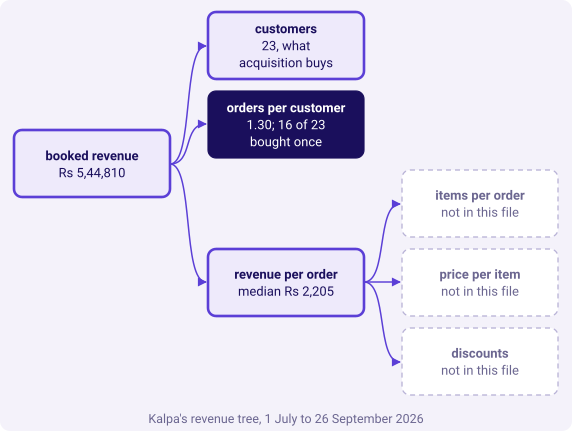

open first: frequency


In [17]:
kit.driver_tree({"label": "booked revenue", "note": kit.rupees(booked_revenue), "kind": "known",
                 "children": [
    {"label": "customers", "note": f"{customers}, what acquisition buys", "kind": "known"},
    {"label": "orders per customer", "note": f"{per_customer:.2f}; {once} of {customers} bought once",
     "kind": "lit"},
    {"label": "revenue per order", "note": f"median {kit.rupees(round(median_order))}",
     "kind": "known", "children": [
        {"label": "items per order", "note": "not in this file", "kind": "unknown"},
        {"label": "price per item", "note": "not in this file", "kind": "unknown"},
        {"label": "discounts", "note": "not in this file", "kind": "unknown"}]}]},
    title="Kalpa's revenue tree, 1 July to 26 September 2026")

# TODO 12. On this evidence, which branch does Meera open first?
#   a) "customers"
#   b) "revenue per order"
#   c) "price"
#   d) "frequency"
first_branch = "frequency"
print("open first:", first_branch)

In [18]:
kit.check("the branch picked is the one the one-time buyers point to", first_branch == "frequency",
          first_branch)

**Why not the others.** Option a is marketing's branch, and the file does not show customers falling;
it shows 16 of 23 customers who never came back, which frequency addresses at a lower cost than
acquisition. Option b rests on a mean one order drags, and on items and prices this file does not
hold. Option c trades volume for price, and part 3 showed a discount losing 6.5 percent of revenue.

### What one window cannot show

These 30 orders cover one quarter. They show the shape of revenue: 23 customers, 1.30 orders each,
a typical order of Rs 2,205, and most customers buying once. They cannot show which branch moved,
because a branch only moves between two windows. Whether customers fell, or frequency fell, or both,
is Tuesday's question, answered with the quarter before this one beside it.

> **Kavya's review.** "Frequency first is a reasoned bet, and it stays a bet until Tuesday's two
> quarters. Say that in the sentence, and ask for the Rs 12 crore to wait until then, which is a no
> for now with a date on it."

## Part 5. The sentence to Meera

One sentence, four parts in this order: the evidence with its window and definition, the branch to
open first, what one window cannot show, and what happens to the Rs 12 crore.

In [19]:
sentence = (f"On the {len(ORDERS)} orders from 1 July to 26 September, {customers} customers "
            f"placed {per_customer:.2f} orders each at a typical order of "
            f"{kit.rupees(round(median_order))}, and {once} of them bought only once, so I would "
            f"open frequency before acquisition; this one window cannot show which branch moved, "
            f"so hold the Rs 12 crore until Tuesday's two quarters.")
print(sentence)

On the 30 orders from 1 July to 26 September, 23 customers placed 1.30 orders each at a typical order of Rs 2,205, and 16 of them bought only once, so I would open frequency before acquisition; this one window cannot show which branch moved, so hold the Rs 12 crore until Tuesday's two quarters.


In [20]:
kit.check("the sentence carries the customers, the rate, the typical order and the one-time buyers",
          str(customers) in sentence and f"{per_customer:.2f}" in sentence
          and kit.rupees(round(median_order)) in sentence and str(once) in sentence)
kit.check("the sentence names the window it cannot see past", "window" in sentence.lower())

A sentence that opens on the branch and ends on the evidence can be as strong, provided every number
carries its definition and the caveat names what Tuesday settles.

### In the interview

**[S] How would you increase sales for an online retailer?** I would start by drawing revenue as a
tree, customers times orders per customer times revenue per order, with revenue per order split into
items, price and discounts, and then put the retailer's own numbers on it. The branch I open first is
the one whose number looks weakest and costs least to move. On Kalpa's quarter, 16 of 23 customers
bought only once, so frequency comes first, and retention ideas such as reorder reminders follow from
that. I would then compare two windows before promising which branch will grow.

**[D] Marketing wants budget for acquisition; what would you check before agreeing it is the right
branch, and how would you say no?** I would count customers by id and see how many came back, value
a new customer's first order at the median of Rs 2,205 rather than the mean of Rs 18,160, and ask for
the quarter before this one to see whether customers actually fell. The no is a no for now with a
date: "Frequency looks like the cheaper branch, since 16 of 23 customers bought once; Tuesday's two
quarters will show whether customers fell, and if they did, acquisition goes first."

**[F] Marketing says a 10 percent lift in customers and a 10 percent lift in frequency make 20
percent growth; what is the right number, and when does the difference matter?** The right number is
21 percent, because the branches multiply: 1.10 x 1.10 = 1.21. On Rs 5,44,810 that is Rs 6,59,220
against Rs 6,53,772, a gap of Rs 5,448. The gap grows with the size and number of lifts; two 30 percent
lifts make 69 percent, and it matters whenever a budget or a target is sized from the sum.

**[D] A 15 percent discount lifts quantity 10 percent; did revenue rise or fall, and what would you
ask next?** It fell 6.5 percent, since 0.85 x 1.10 = 0.935, taking Rs 5,44,810 to Rs 5,09,397. Next I
would ask whether the extra orders came from new or existing customers, whether they were pulled
forward from later weeks, what the discount does to margin, and whether quantity could rise the 17.6
percent needed to break even on revenue.

## What the case established

Five parts, each with its number, make one answer Meera can defend on Thursday.

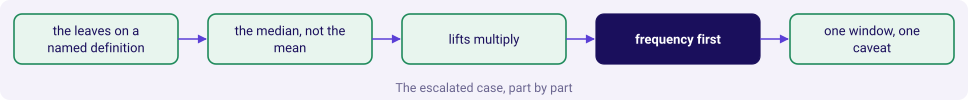

Part,What it established
1. the leaves,"booked: 30 orders, 23 customers, 1.30 each; delivered: 21, 19, 1.11"
2. the typical order,"median Rs 2,205 against a mean of Rs 18,160; 1 of 30 above the mean"
3. the tree arithmetic,"two 10 percent lifts make 21 percent, Rs 6,59,220; the discount is a 6.5 percent fall"
4. the branch,frequency: 16 of 23 customers bought once
5. the caveat,one window shows the shape of revenue; two windows show which branch moved


In [21]:
kit.flow(["the leaves on a named definition", "the median, not the mean", "lifts multiply",
          "frequency first", "one window, one caveat"],
         kinds=["good", "good", "good", "lit", "good"], title="The escalated case, part by part")
kit.table(["Part", "What it established"], [
    ("1. the leaves", f"booked: {len(ORDERS)} orders, {customers} customers, {per_customer:.2f} each; "
                      f"delivered: {len(delivered)}, {delivered_customers}, {delivered_per_customer:.2f}"),
    ("2. the typical order", f"median {kit.rupees(round(median_order))} against a mean of "
                             f"{kit.rupees(round(mean_order))}; {above_mean} of {n} above the mean"),
    ("3. the tree arithmetic", f"two 10 percent lifts make {growth * 100:.0f} percent, "
                               f"{kit.rupees(round(after_both))}; the discount is a "
                               f"{(1 - discount_factor) * 100:.1f} percent fall"),
    ("4. the branch", f"{first_branch}: {once} of {customers} customers bought once"),
    ("5. the caveat", "one window shows the shape of revenue; two windows show which branch moved"),
])

In [22]:
kit.check_summary()
print("Next: the second case asks whether one channel changes this recommendation.")

Next: the second case asks whether one channel changes this recommendation.
